In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor

plt.rcdefaults()
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.sans-serif'] = ['Arial']

def mackey_glass_derivative(x, x_tau, beta, gamma):
    dxdt = beta * x_tau / (1 + x_tau**10) - gamma * x
    return dxdt


def runge_kutta4_step(x, x_tau, beta, gamma, dt):
    k1 = mackey_glass_derivative(x, x_tau, beta, gamma)
    k2 = mackey_glass_derivative(x + 0.5 * dt * k1, x_tau, beta, gamma)
    k3 = mackey_glass_derivative(x + 0.5 * dt * k2, x_tau, beta, gamma)
    k4 = mackey_glass_derivative(x + dt * k3, x_tau, beta, gamma)

    return x + (dt / 6.0) * (k1 + 2*k2 + 2*k3 + k4)


def generate_mackey_glass_rk4(tau, beta, gamma, n, dt=1):
    mg_series = np.zeros(n)
    x = 1.2  # initial point

    for i in range(n):
        x_tau = mg_series[max(0, i - tau)]
        x = runge_kutta4_step(x, x_tau, beta, gamma, dt)
        mg_series[i] = x

    return mg_series


def normalize(series, a, b):
    min = np.min(series)
    max = np.max(series)
    normalized = a + ((series - min) / (max - min)) * (b - a)
    return normalized


def build_dataset_MLP(input, target, ampl_variation, N_train, N_virtual_node, future_step):
    X_train = np.zeros((N_train, N_virtual_node * ampl_variation))
    Y_train = np.zeros(N_train)
    for i in range(N_train):
        for j in range(ampl_variation):
            X_train[i, j*N_virtual_node:(j+1)*N_virtual_node] = input[j][i:(i+N_virtual_node)]
        Y_train[i] = target[N_virtual_node+i+(future_step-1)]

    X_test = np.zeros((N_test, N_virtual_node * ampl_variation))
    Y_test = np.zeros(N_test)
    for i in range(N_test):
        for j in range(ampl_variation):
            X_test[i, j*N_virtual_node:(j+1)*N_virtual_node] = input[j][(N_train+i): (N_train+N_virtual_node+i)]
        Y_test[i] = target[N_train+N_virtual_node+i+(future_step-1)]

    return X_train, Y_train, X_test, Y_test


def add_awgn_noise(signal, snr_db, noise_seed=None):
    # Add noise to the original series
    signal = np.asarray(signal, dtype=float)

    if snr_db is None or np.isposinf(snr_db):
        noisy_signal = signal.copy()
        noise = np.zeros_like(signal)

        return noisy_signal

    signal_power = np.mean(signal ** 2)
    snr_linear = 10 ** (snr_db / 10)
    noise_power = signal_power / snr_linear
    noise_std = np.sqrt(noise_power)

    rng = np.random.default_rng(noise_seed)
    noise = rng.normal(loc=0.0,scale=noise_std,size=signal.shape)

    noisy_signal = signal + noise

    return noisy_signal


tau, beta, gamma, n = 18, 0.2, 0.1, 5000
mg_series_rk4 = generate_mackey_glass_rk4(tau, beta, gamma, n)
mg_normalized = normalize(mg_series_rk4, 0, 1)



### MLP 450 * 64 * 1

- SNR = np.inf

In [ ]:
# Generate input mask
rng = np.random.default_rng(0)
input_ampl = rng.uniform(0.0, 1.0, size=9).astype(np.float64)

MG_input_variant = np.zeros((len(input_ampl), len(mg_normalized)))
MG_input_variant_noisy = np.zeros((len(input_ampl), len(mg_normalized)))

SNR_DB = np.inf

for i in range(len(input_ampl)):
    MG_input_variant[i] = mg_normalized * input_ampl[i]
    MG_input_variant_noisy[i] = add_awgn_noise(MG_input_variant[i], snr_db=SNR_DB, noise_seed=0)

################ Dataset preparation ################
N_virtual_node = 50
N_train = 1200
N_test = 500
ampl_variation = 9

future_steps = np.arange(1, 31)
seeds = np.arange(5)

################ Store results ################
nrmse_test_all = np.zeros((len(future_steps), len(seeds)))

################ Loop over future_step ################
for i, future_step in enumerate(future_steps):

    print("=" * 60)
    print(f"future_step = {future_step}")
    print("=" * 60)

    # Build dataset once for each future_step
    X_train, Y_train, X_test, Y_test = build_dataset_MLP(
        MG_input_variant_noisy,
        mg_normalized,
        ampl_variation=ampl_variation,
        N_train=N_train,
        N_virtual_node=N_virtual_node,
        future_step=future_step
    )

    Y_train_1d = Y_train.ravel()
    Y_test_1d = Y_test.ravel()

    # Standardize once for each future_step
    X_scaler = StandardScaler()
    y_scaler = StandardScaler()

    X_train_scaled = X_scaler.fit_transform(X_train)
    X_test_scaled = X_scaler.transform(X_test)

    y_train_scaled = y_scaler.fit_transform(
        Y_train_1d.reshape(-1, 1)
    ).ravel()

    for j, seed in enumerate(seeds):

        mlp = MLPRegressor(
            hidden_layer_sizes=(64,),      
            activation='relu',
            solver='adam',
            alpha=1e-2,
            batch_size=32,
            learning_rate_init=5e-4,
            max_iter=500,                  
            tol=1e-4,                      
            n_iter_no_change=20,           
            early_stopping=False,
            random_state=int(seed),
            verbose=False,
        )

        mlp.fit(X_train_scaled, y_train_scaled)

        Y_test_predict_scaled = mlp.predict(X_test_scaled)

        Y_test_predict = y_scaler.inverse_transform(
            Y_test_predict_scaled.reshape(-1, 1)
        ).ravel()

        nmse_test = np.mean((Y_test_predict - Y_test_1d) ** 2) / np.var(Y_test_1d)
        nrmse_test = np.sqrt(nmse_test)

        nrmse_test_all[i, j] = nrmse_test

    print(
        f"averaged test NRMSE = {np.mean(nrmse_test_all[i, :]):.6f}"
    )

nrmse_test_mean_no_noise = np.mean(nrmse_test_all, axis=1)
nrmse_test_std_no_noise = np.std(nrmse_test_all, axis=1)

np.savetxt('MG_MLP_nrmse_test_mean_no_noise.txt', nrmse_test_mean_no_noise)
np.savetxt('MG_MLP_nrmse_test_std_no_noise.txt', nrmse_test_std_no_noise)

future_step = 1
averaged test NRMSE = 0.029160
future_step = 2
averaged test NRMSE = 0.020808
future_step = 3
averaged test NRMSE = 0.021642
future_step = 4
averaged test NRMSE = 0.023167
future_step = 5
averaged test NRMSE = 0.033970
future_step = 6
averaged test NRMSE = 0.039749
future_step = 7
averaged test NRMSE = 0.029843
future_step = 8
averaged test NRMSE = 0.037103
future_step = 9
averaged test NRMSE = 0.033040
future_step = 10
averaged test NRMSE = 0.055042
future_step = 11
averaged test NRMSE = 0.046796
future_step = 12
averaged test NRMSE = 0.062077
future_step = 13
averaged test NRMSE = 0.063192
future_step = 14
averaged test NRMSE = 0.051557
future_step = 15
averaged test NRMSE = 0.053942
future_step = 16
averaged test NRMSE = 0.039301
future_step = 17
averaged test NRMSE = 0.057387
future_step = 18
averaged test NRMSE = 0.054840
future_step = 19
averaged test NRMSE = 0.055935
future_step = 20
averaged test NRMSE = 0.063048
future_step = 21
averaged test NRMSE = 0.055800
f

- SNR = 30 dB

In [ ]:
# Generate input mask
rng = np.random.default_rng(0)
input_ampl = rng.uniform(0.0, 1.0, size=9).astype(np.float64)

MG_input_variant = np.zeros((len(input_ampl), len(mg_normalized)))
MG_input_variant_noisy = np.zeros((len(input_ampl), len(mg_normalized)))

SNR_DB = 30

for i in range(len(input_ampl)):
    MG_input_variant[i] = mg_normalized * input_ampl[i]
    MG_input_variant_noisy[i] = add_awgn_noise(MG_input_variant[i], snr_db=SNR_DB, noise_seed=0)

################ Dataset preparation ################
N_virtual_node = 50
N_train = 1200
N_test = 500
ampl_variation = 9

future_steps = np.arange(1, 31)
seeds = np.arange(5)

################ Store results ################
nrmse_test_all = np.zeros((len(future_steps), len(seeds)))

################ Loop over future_step ################
for i, future_step in enumerate(future_steps):

    print("=" * 60)
    print(f"future_step = {future_step}")
    print("=" * 60)

    # Build dataset once for each future_step
    X_train, Y_train, X_test, Y_test = build_dataset_MLP(
        MG_input_variant_noisy,
        mg_normalized,
        ampl_variation=ampl_variation,
        N_train=N_train,
        N_virtual_node=N_virtual_node,
        future_step=future_step
    )

    Y_train_1d = Y_train.ravel()
    Y_test_1d = Y_test.ravel()

    # Standardize once for each future_step
    X_scaler = StandardScaler()
    y_scaler = StandardScaler()

    X_train_scaled = X_scaler.fit_transform(X_train)
    X_test_scaled = X_scaler.transform(X_test)

    y_train_scaled = y_scaler.fit_transform(
        Y_train_1d.reshape(-1, 1)
    ).ravel()

    for j, seed in enumerate(seeds):

        mlp = MLPRegressor(
            hidden_layer_sizes=(64,),    
            activation='relu',
            solver='adam',
            alpha=1e-2,
            batch_size=32,
            learning_rate_init=5e-4,
            max_iter=1500,                 
            tol=1e-4,                    
            n_iter_no_change=20,           
            early_stopping=False,
            random_state=int(seed),
            verbose=False,
        )

        mlp.fit(X_train_scaled, y_train_scaled)

        Y_test_predict_scaled = mlp.predict(X_test_scaled)

        Y_test_predict = y_scaler.inverse_transform(
            Y_test_predict_scaled.reshape(-1, 1)
        ).ravel()

        nmse_test = np.mean((Y_test_predict - Y_test_1d) ** 2) / np.var(Y_test_1d)
        nrmse_test = np.sqrt(nmse_test)

        nrmse_test_all[i, j] = nrmse_test

    print(
        f"averaged test NRMSE={np.mean(nrmse_test_all[i, :]):.6f}"
    )

nrmse_test_mean_snr30 = np.mean(nrmse_test_all, axis=1)
nrmse_test_std_snr30 = np.std(nrmse_test_all, axis=1)

np.savetxt('MG_MLP_nrmse_test_mean_snr30.txt', nrmse_test_mean_snr30)
np.savetxt('MG_MLP_nrmse_test_std_snr30.txt', nrmse_test_std_snr30)

future_step = 1
averaged test NRMSE=0.046765
future_step = 2
averaged test NRMSE=0.051867
future_step = 3
averaged test NRMSE=0.050890
future_step = 4
averaged test NRMSE=0.064643
future_step = 5
averaged test NRMSE=0.060710
future_step = 6
averaged test NRMSE=0.071127
future_step = 7
averaged test NRMSE=0.075244
future_step = 8
averaged test NRMSE=0.072321
future_step = 9
averaged test NRMSE=0.084016
future_step = 10
averaged test NRMSE=0.072194
future_step = 11
averaged test NRMSE=0.084435
future_step = 12
averaged test NRMSE=0.080848
future_step = 13
averaged test NRMSE=0.091280
future_step = 14
averaged test NRMSE=0.076611
future_step = 15
averaged test NRMSE=0.092202
future_step = 16
averaged test NRMSE=0.101621
future_step = 17
averaged test NRMSE=0.081850
future_step = 18
averaged test NRMSE=0.093401
future_step = 19
averaged test NRMSE=0.081464
future_step = 20
averaged test NRMSE=0.097200
future_step = 21
averaged test NRMSE=0.087806
future_step = 22
averaged test NRMSE=0.0940

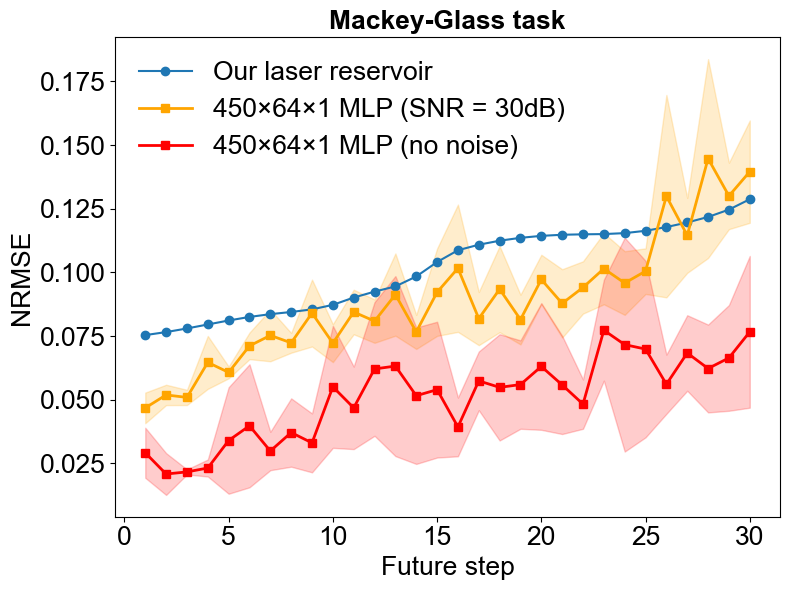

In [2]:
future_steps = np.arange(1, 31)

nrmse_test_mean_snr30 = np.loadtxt('MG_MLP_nrmse_test_mean_snr30.txt')
nrmse_test_std_snr30 = np.loadtxt('MG_MLP_nrmse_test_std_snr30.txt')

nrmse_test_mean_no_noise = np.loadtxt('MG_MLP_nrmse_test_mean_no_noise.txt')
nrmse_test_std_no_noise = np.loadtxt('MG_MLP_nrmse_test_std_no_noise.txt')

laser_reservoir = [0.07535968, 0.07654316, 0.07796828, 0.079532  , 0.08109658,
       0.08249487, 0.08358596, 0.08443798, 0.085461  , 0.08723551,
       0.09009996, 0.0924345 , 0.09448102, 0.09837375, 0.10405612,
       0.10868259, 0.11084949, 0.11242845, 0.11355823, 0.11432738,
       0.11476409, 0.11493129, 0.11503233, 0.11540294, 0.1163191 ,
       0.11777911, 0.11958961, 0.12174755, 0.12463165, 0.12870678]

plt.figure(figsize=(8, 6))

plt.plot(future_steps, laser_reservoir, marker='o', label='Our laser reservoir')

plt.plot(
    future_steps,
    nrmse_test_mean_snr30,
    marker='s',
    linewidth=2,
    label='450×64×1 MLP (SNR = 30dB)',
    color='orange'
)

plt.fill_between(
    future_steps,
    nrmse_test_mean_snr30 - nrmse_test_std_snr30,
    nrmse_test_mean_snr30 + nrmse_test_std_snr30,
    alpha=0.2,
    color='orange'
)

plt.plot(
    future_steps,
    nrmse_test_mean_no_noise,
    marker='s',
    linewidth=2,
    label='450×64×1 MLP (no noise)',
    color='red'
)

plt.fill_between(
    future_steps,
    nrmse_test_mean_no_noise - nrmse_test_std_no_noise,
    nrmse_test_mean_no_noise + nrmse_test_std_no_noise,
    alpha=0.2,
    color='red'
)

font = 19
plt.xlabel('Future step', fontsize=font)
plt.ylabel('NRMSE', fontsize=font)
plt.title('Mackey-Glass task', fontsize=font, weight='bold')
plt.legend(frameon=0, fontsize=font)
plt.xticks(fontsize=font)
plt.yticks(fontsize=font)
plt.tight_layout()
plt.show()
# plt.savefig('Mackey-Glass MLP.png', dpi=800, transparent=1)